# Loss of Heterozygosity (LOHet) Calculation Pipeline

This notebook calculates Loss of Heterozygosity (LOH) across genomic regions using variant data. LOHet is an important signal of genomic instability and can indicate structural variation, selective sweeps, or adaptation events.

This notebook was done on Google Colab because it allows the usage of pysam.

## Overview

The workflow:
1. Loads variant data (e.g., VCF-derived or processed SNP tables)
2. Identifies heterozygous sites in ancestral samples
3. Tracks allele states in descendant or comparison samples
4. Detects regions where heterozygosity is lost
5. Aggregates LOH events across the genome
6. Outputs summaries and visualizations

## Key Concepts

- **Heterozygosity**: Presence of two different alleles at a locus
- **LOH (Loss of Heterozygosity)**: Transition from heterozygous → homozygous state
- **Genomic Windowing**: Grouping variants into regions for analysis
- **Comparative Genomics**: Evaluating differences across samples


In [1]:
!pip install pysam
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 30.9 MB/s eta 0:00:00


In [12]:
# Required imports for notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pysam import VariantFile
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [6]:
# Upload all_chromosomes_combined.vcf

from google.colab import files

uploaded = files.upload()

Saving all_chromosomes_combined.vcf to all_chromosomes_combined (1).vcf


In [7]:
# Load the VCF file
vcf_path = "all_chromosomes_combined.vcf"  # or .vcf.gz
vcf_in = VariantFile(vcf_path)

# Preview header
lengths = {ctg: ctg_data.length for ctg, ctg_data in vcf_in.header.contigs.items()}
print(lengths)

# Preview samples in VCF
samples = list(vcf_in.header.samples)
samples

{'chr1': 230218, 'chr2': 813184, 'chr3': 316620, 'chr4': 1531933, 'chr5': 576874, 'chr6': 270161, 'chr7': 1090940, 'chr8': 562643, 'chr9': 439888, 'chr10': 745751, 'chr11': 666816, 'chr12': 1078177, 'chr13': 924431, 'chr14': 784333, 'chr15': 1091291, 'chr16': 948066, 'chrM': 85779}


['892B',
 '942',
 'CNTL1_A01_SD_S240',
 'CNTL1_B01_SD_S241',
 'CNTL1_E_A02_Other_S280',
 'CNTL1_E_H01_NAT_S271',
 'CNTL2_A04_SD_S242',
 'CNTL2_B04_SD_S243',
 'CNTL3_A06_SD_S244',
 'CNTL3_B06_SD_S245',
 'CNTL4_A08_SD_S246',
 'CNTL4_B08_SD_S247',
 'CNTL4_P2_B09_NAT_S272',
 'CNTL5_A10_SD_S248',
 'CNTL5_B10_SD_S249',
 'CNTL5_E_H02_Other_S281',
 'COM1_B01_SD_S230',
 'COM1_C01_SD_S231',
 'COM1_E_E01_NAT_S261',
 'COM2_C03_SD_S232',
 'COM2_D03_SD_S233',
 'COM2_FP2_D10_NAT_S262',
 'COM2_FP2_E10_NAT_S263',
 'COM2_FP2_F10_NAT_S264',
 'COM3_E05_SD_S234',
 'COM3_E_F01_NAT_S265',
 'COM3_F05_SD_S235',
 'COM4_C09_NAT_S266',
 'COM4_FP2_F11_NAT_S267',
 'COM4_FP2_G11_NAT_S268',
 'COM4_G07_SD_S236',
 'COM4_H07_SD_S237',
 'COM5_D10_SD_S238',
 'COM5_E10_SD_S239',
 'COM5_FP2_C12_Other_S279',
 'COM5_FP2_H12_NAT_S270',
 'COM5_G11_NAT_S269',
 'ERR1308867',
 'NAT1_B01_SD_S220',
 'NAT1_C01_SD_S221',
 'NAT1_FP2_B03_NAT_S251',
 'NAT1_FP2_G01_NAT_S250',
 'NAT2_C03_SD_S222',
 'NAT2_D03_SD_S223',
 'NAT2_FP2_C04_Other_

In [8]:
# Define which fields to extract
records = {
    "CHROM": [], "POS": [],
}

for sm in samples:
    records[sm+"_gt"] = []

for record in vcf_in.fetch():
    records["CHROM"].append(record.contig)
    records["POS"].append(record.pos)

    for sm in record.samples:
        sample_data = record.samples[sm]
        genotype = sample_data.get("GT")
        records[sm+"_gt"].append(genotype)

# Convert to DataFrame
df_vcf = pd.DataFrame.from_dict(records)

df_vcf.head()

,CHROM,POS,892B_gt,942_gt,CNTL1_A01_SD_S240_gt,CNTL1_B01_SD_S241_gt,CNTL1_E_A02_Other_S280_gt,CNTL1_E_H01_NAT_S271_gt,CNTL2_A04_SD_S242_gt,CNTL2_B04_SD_S243_gt,...,SD2_H01_SD_S210_gt,SD3_C02_SD_S211_gt,SD3_D02_SD_S212_gt,SD3_E02_SD_S213_gt,SD4_A03_SD_S214_gt,SD4_B03_SD_S215_gt,SD4_C03_SD_S216_gt,SD5_F03_SD_S217_gt,SD5_G03_SD_S218_gt,SD5_H03_SD_S219_gt
0,chr1,22,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,"(0, 0)","(0, 0)","(0, 1)","(0, 1)","(0, 0)","(None, None)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
1,chr1,25,"(0, 0)","(0, 0)","(0, 2)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,"(0, 0)","(0, 0)","(0, 1)","(0, 1)","(0, 0)","(None, None)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
2,chr1,26,"(0, 0)","(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,"(0, 0)","(0, 0)","(0, 1)","(0, 1)","(0, 0)","(None, None)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
3,chr1,27,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,"(0, 0)","(0, 0)","(0, 1)","(0, 1)","(0, 0)","(None, None)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
4,chr1,29,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"


In [9]:
# Identifies heterozygous genotype calls for each sample in the dataset and
# appends the results as new boolean columns
is_het = lambda gt: len(set(gt)) > 1
for sm in samples:
    df_vcf = df_vcf.assign(**{f"{sm}_is_het": df_vcf[f"{sm}_gt"].apply(is_het)})

df_vcf

,CHROM,POS,892B_gt,942_gt,CNTL1_A01_SD_S240_gt,CNTL1_B01_SD_S241_gt,CNTL1_E_A02_Other_S280_gt,CNTL1_E_H01_NAT_S271_gt,CNTL2_A04_SD_S242_gt,CNTL2_B04_SD_S243_gt,...,SD2_H01_SD_S210_is_het,SD3_C02_SD_S211_is_het,SD3_D02_SD_S212_is_het,SD3_E02_SD_S213_is_het,SD4_A03_SD_S214_is_het,SD4_B03_SD_S215_is_het,SD4_C03_SD_S216_is_het,SD5_F03_SD_S217_is_het,SD5_G03_SD_S218_is_het,SD5_H03_SD_S219_is_het
0,chr1,22,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,False,True,True,False,False,False,False,False,False
1,chr1,25,"(0, 0)","(0, 0)","(0, 2)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,False,True,True,False,False,False,False,False,False
2,chr1,26,"(0, 0)","(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,False,True,True,False,False,False,False,False,False
3,chr1,27,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,False,True,True,False,False,False,False,False,False
4,chr1,29,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174879,chr16,947930,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,False,False,False,False,False,False,False,False,False
174880,chr16,947943,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,False,False,False,False,False,False,False,False,False
174881,chr16,947947,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,False,False,False,False,False,False,False,False,False
174882,chr16,947967,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)",...,False,False,False,False,False,False,False,False,False,False


In [13]:
'''
Width ratio calculation (for plotting layouts)
------------------------------------------------
- `lengths` is assumed to be a dictionary:
    {chromosome_name: chromosome_length}

- Mitochondrial chromosome ('chrM') is excluded.
- The total genome length (excluding chrM) is computed.
- Each chromosome length is normalized by this total to produce a
  proportional width (`width_ratios`).

- `width_ratios` can be used in plotting (e.g., matplotlib subplots)
  to scale chromosome panels relative to their genomic size.

- `sum(width_ratios)` should be ~1.0 (sanity check).
'''

width_ratios = []
sum_length = sum([clen for ctg, clen in lengths.items() if ctg != 'chrM'])
for ctg, clen in lengths.items():
    if ctg == 'chrM':
        continue
    rlen = clen/sum_length
    width_ratios.append(rlen)

sum(width_ratios)

1.0

In [14]:
'''
Windowed heterozygosity calculation
--------------------------------------
- `df_vcf` is a DataFrame containing variant data with at least:
    - "CHROM": chromosome name
    - "POS": genomic position
    - "<sample>_is_het": boolean (True = heterozygous)

- `samples` is a list of sample names.

- `window_size` defines genomic bin size (e.g., 500 bp).
'''

windowed_heterozygosity = {}
window_size = 500

for ctg, clen in lengths.items():
    # Create genomic bins
    bins = np.arange(0, clen, window_size)
    # Subset variants for chromosome
    ctg_het = df_vcf.query("CHROM == @ctg")
    # Assign each variant to a bin
    ctg_het = ctg_het.assign(BIN=pd.cut(ctg_het["POS"], bins))
    # Group variants by bin
    windows = ctg_het.groupby(by="BIN", observed=False)

    windowed_heterozygosity[ctg] = {}
    for sm in samples :
        het_wins = []
        for _, win in windows:
            sample_col = f"{sm}_is_het"
            n_het = win[sample_col].sum()
            het = n_het / window_size
            het_wins.append(het)

        windowed_heterozygosity[ctg][sm] = (bins, het_wins)

In [17]:
# Sourdough and Nature Samples + List of Chromosomes

sd_ids = ["CNTL4_A08_SD_S246",
                   "COM5_D10_SD_S238",
                   "COM1_C01_SD_S231",
                   "NAT2_D03_SD_S223",
                   "NAT1_C01_SD_S221",
                   "CNTL1_B01_SD_S241",
                   "SD4_B03_SD_S215",
                   "SD1_A01_SD_S205",
                   "NAT1_B01_SD_S220",
                   "SD3_E02_SD_S213",
                   "SD2_F01_SD_S208",
                   "COM4_H07_SD_S237",
                   "NAT5_A10_SD_S228",
                   "COM3_E05_SD_S234",
                   "CNTL3_A06_SD_S244",
                   "COM5_E10_SD_S239",
                   "NAT4_E08_SD_S227",
                  "COM2_C03_SD_S232",
                   "NAT3_F05_SD_S225",
                   "SD3_C02_SD_S211",
                   "COM1_B01_SD_S230",
                   "SD5_H03_SD_S219",
                   "CNTL5_B10_SD_S249",
                   "SD2_H01_SD_S210",
                   "NAT5_B10_SD_S229",
                   "CNTL4_B08_SD_S247",
                   "CNTL2_B04_SD_S243",
                   "SD4_A03_SD_S214",
                   "CNTL1_A01_SD_S240",
                   "NAT3_E05_SD_S224",
                   "CNTL2_A04_SD_S242",
                   "SD3_D02_SD_S212",
                   "CNTL3_B06_SD_S245",
                   "SD1_C01_SD_S207",
                   "NAT2_C03_SD_S222",
                   "SD1_B01_SD_S206",
                   "SD5_G03_SD_S218",
                   "CNTL5_A10_SD_S248",
                   "COM3_F05_SD_S235",
                   "NAT4_H07_NAT_S256",
                   "COM4_G07_SD_S236",
                   "NAT4_D08_SD_S226",
                   "COM2_D03_SD_S233",
                   "SD4_C03_SD_S216",
                   "NAT2_H03_Other_S274",
                   "SD5_F03_SD_S217"]

nat_ids = [
                "CNTL4_P2_B09_NAT_S272",
                "COM5_FP2_H12_NAT_S270",
                "NAT3_E_A01_NAT_S255",
                "CNTL1_E_H01_NAT_S271",
                "COM1_E_E01_NAT_S261",
                "COM4_FP2_F11_NAT_S267",
                "NAT3_B06_NAT_S253",
                "NAT2_FP2_E03_NAT_S252",
                "NAT1_FP2_B03_NAT_S251",
                "NAT3_F06_NAT_S254",
                "COM2_FP2_E10_NAT_S263",
                "COM2_FP2_D10_NAT_S262",
                "NAT1_FP2_G01_NAT_S250",
                "NAT5_FP2_B09_NAT_S259",
                "NAT5_FP2_H09_NAT_S260",
                "NAT5_FP2_A08_NAT_S283",
                "NAT4_FP2_E07_NAT_S257",
                "COM3_E_F01_NAT_S265",
                "COM4_FP2_G11_NAT_S268",
                "COM2_FP2_F10_NAT_S264",
                "NAT2_FP2_C04_Other_S273",
                "NAT5_FP2_H07_NAT_S258",
                "COM5_G11_NAT_S269",
                "NAT4_FP2_E05_NAT_S282",
                "NAT5_FP2_H08_Other_S277",
                "NAT5_FP2_D08_Other_S275"]

chrom_list = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16']

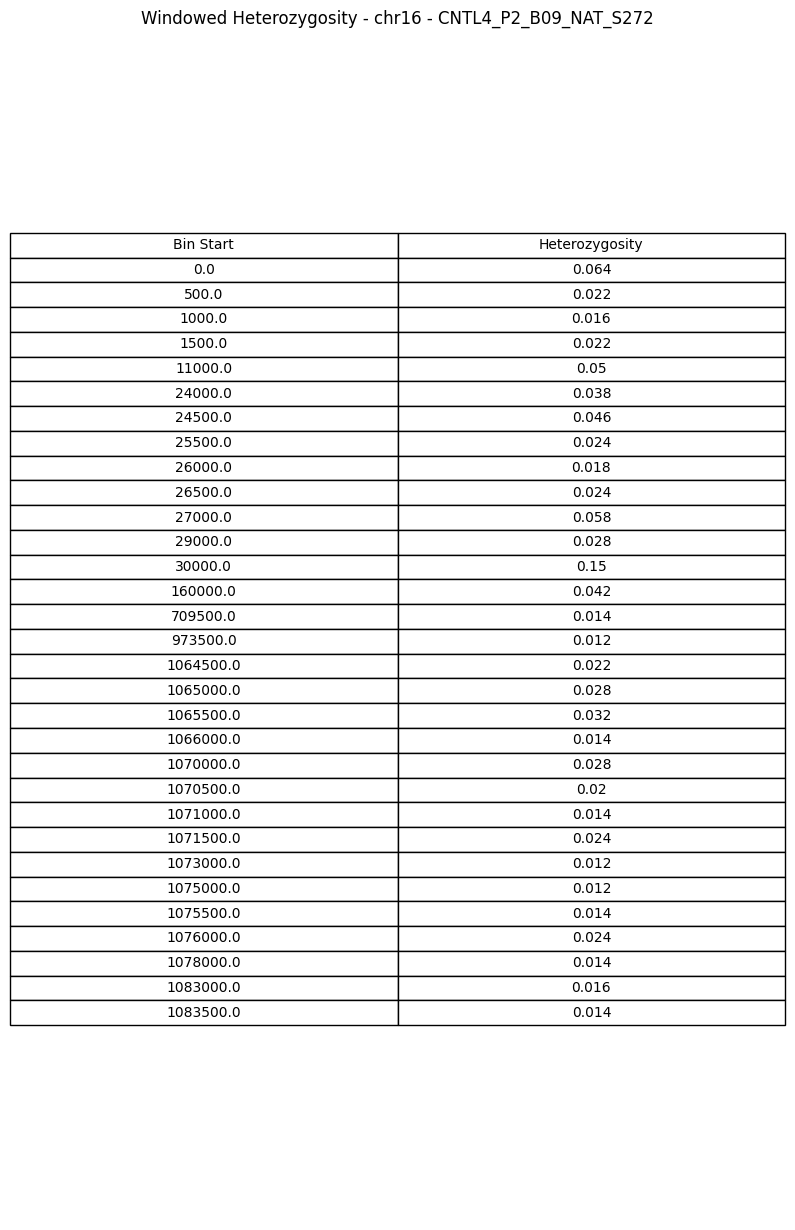

In [16]:
# Extract bins and heterozygosity values
bins, het_values = windowed_heterozygosity['chr15']['CNTL4_P2_B09_NAT_S272']
bins = bins[:len(het_values)]  # Trim to match het_values
rev_bins = []
rev_vals = []
for i in range(0,len(het_values)):
    if het_values[i] >= 0.01:
        rev_bins.append(bins[i])
        rev_vals.append(het_values[i])
# Create a DataFrame
df = pd.DataFrame({
    "Bin Start": rev_bins,
    "Heterozygosity": rev_vals
})
# Display as table using matplotlib
fig, ax = plt.subplots(figsize=(8, 0.4 * len(df)))
ax.axis("off")
table = ax.table(
    cellText=df.round(4).values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center',
    colLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title("Windowed Heterozygosity - chr16 - CNTL4_P2_B09_NAT_S272", fontsize=12, pad=10)
plt.tight_layout()
plt.show()


In [18]:
# Plotting Nature Ancestor vs Descendant Heterozygosity

chromosomes = [f"chr{i}" for i in range(1, 17)]
ancestor = "ERR1308867"

# Identify sourdough samples (excluding ancestor)
nature_samples = [s for s in nat_ids]

# Window size used in binning
window_size = 500

# Build cumulative genome mapping
x_ticks = []
x_tick_labels = []
cumulative_x = 0
genome_x = {}

for chrom in chromosomes:
    bins, het_values = windowed_heterozygosity[chrom][ancestor]
    bins = bins[:len(het_values)]
    bins = bins / window_size
    bins = bins.tolist()

    n_windows = len(het_values)
    genome_x[chrom] = (cumulative_x, cumulative_x + n_windows)
    midpoint = cumulative_x + n_windows // 2
    x_ticks.append(midpoint)
    x_tick_labels.append(chrom)
    cumulative_x += n_windows

# Create a multi-page PDF with 1 plot per page
output_pdf = "heterozygosity_ERR1308867_vs_nature_samples.pdf"
with PdfPages(output_pdf) as pdf:
    for sample in nature_samples:
        fig, ax = plt.subplots(figsize=(18, 4))

        x_values = []
        ancestor_vals = []
        sample_vals = []

        for chrom in chromosomes:
            a_bins, a_vals = windowed_heterozygosity[chrom][ancestor]
            s_bins, s_vals = windowed_heterozygosity[chrom][sample]

            start = genome_x[chrom][0]
            x = list(range(start, start + len(a_vals)))

            x_values.extend(x)
            ancestor_vals.extend(a_vals)
            sample_vals.extend(s_vals)

        ax.plot(x_values, ancestor_vals, color="gray", alpha=0.4, label="Ancestor (ERR1308867)")
        ax.plot(x_values, sample_vals, color="blue", label=sample)

        ax.set_title(f"Heterozygosity: ERR1308867 vs. {sample}", fontsize=12)
        ax.set_ylabel("Heterozygosity")
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels, rotation=90, fontsize=8)
        ax.set_xlabel("Genome (Chromosomes 1–16)")
        ax.legend(fontsize=8)

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved to {output_pdf}")

Saved to heterozygosity_ERR1308867_vs_nature_samples.pdf


In [19]:
# Plotting Sourdough Ancestor vs Descendant Heterozygosity

chromosomes = [f"chr{i}" for i in range(1, 17)]
ancestor = "892B"

# Identify sourdough samples (excluding ancestor)
sourdough_samples = [s for s in sd_ids]

# Window size used in binning
window_size = 500

# Build cumulative genome mapping
x_ticks = []
x_tick_labels = []
cumulative_x = 0
genome_x = {}

for chrom in chromosomes:
    bins, het_values = windowed_heterozygosity[chrom][ancestor]
    bins = bins[:len(het_values)]
    bins = bins / window_size
    bins = bins.tolist()

    n_windows = len(het_values)
    genome_x[chrom] = (cumulative_x, cumulative_x + n_windows)
    midpoint = cumulative_x + n_windows // 2
    x_ticks.append(midpoint)
    x_tick_labels.append(chrom)
    cumulative_x += n_windows

# Create a multi-page PDF with 1 plot per page
output_pdf = "heterozygosity_892B_vs_sourdough_samples.pdf"
with PdfPages(output_pdf) as pdf:
    for sample in sourdough_samples:
        fig, ax = plt.subplots(figsize=(18, 4))

        x_values = []
        ancestor_vals = []
        sample_vals = []

        for chrom in chromosomes:
            a_bins, a_vals = windowed_heterozygosity[chrom][ancestor]
            s_bins, s_vals = windowed_heterozygosity[chrom][sample]

            start = genome_x[chrom][0]
            x = list(range(start, start + len(a_vals)))

            x_values.extend(x)
            ancestor_vals.extend(a_vals)
            sample_vals.extend(s_vals)

        ax.plot(x_values, ancestor_vals, color="gray", alpha=0.4, label="Ancestor (892B)")
        ax.plot(x_values, sample_vals, color="blue", label=sample)

        ax.set_title(f"Heterozygosity: 892B vs. {sample}", fontsize=12)
        ax.set_ylabel("Heterozygosity")
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels, rotation=90, fontsize=8)
        ax.set_xlabel("Genome (Chromosomes 1–16)")
        ax.legend(fontsize=8)

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved to {output_pdf}")

Saved to heterozygosity_892B_vs_sourdough_samples.pdf


In [20]:
# Initialize empty DataFrames to store LOH (Loss of Heterozygosity) results
# for sourdough (sd) and natural (nat) sample groups
sd_df = pd.DataFrame(columns=['Sample', 'Chromosome', 'Bin'])
nat_df = pd.DataFrame(columns=['Sample', 'Chromosome', 'Bin'])

# Identify Loss of Heterozygosity (LOHet) events
def find_lohet(ancestor, sample_list, df):

  # Lists to collect LOHet events
  sample_name = []
  chrom_name = []
  bin_id = []
  # Iterate through each sample and chromosome
  for sample in sample_list:
    for chrom in chrom_list:
      # Retrieve window bins and heterozygosity values
      sample_bins, sample_het = windowed_heterozygosity[chrom][sample]
      ancestor_bins, ancestor_het = windowed_heterozygosity[chrom][ancestor]
      # Iterate through each genomic window
      for i in range(len(sample_het)):
        # Ancestor has heterozygosity and sample has none - loss of heterozygosity
        if ancestor_het[i] > 0 and sample_het[i] == 0:
          sample_name.append(sample)
          chrom_name.append(chrom)
          bin_id.append(sample_bins[i])
  # Store results in provided DataFrame
  df['Sample'] = sample_name
  df['Chromosome'] = chrom_name
  df['Bin'] = bin_id
  return df

find_lohet("892B", sd_ids, sd_df)
find_lohet("ERR1308867", nat_ids, nat_df)

,Sample,Chromosome,Bin
0,CNTL4_P2_B09_NAT_S272,chr1,11500
1,CNTL4_P2_B09_NAT_S272,chr1,16500
2,CNTL4_P2_B09_NAT_S272,chr1,17000
3,CNTL4_P2_B09_NAT_S272,chr1,17500
4,CNTL4_P2_B09_NAT_S272,chr1,21000
...,...,...,...
14805,NAT5_FP2_D08_Other_S275,chr16,868000
14806,NAT5_FP2_D08_Other_S275,chr16,876000
14807,NAT5_FP2_D08_Other_S275,chr16,887500
14808,NAT5_FP2_D08_Other_S275,chr16,897000


In [21]:
# Set bin size
BIN_SIZE = 500

# Function to find consecutive bin runs
def find_consecutive_runs(df, bin_size=BIN_SIZE):
    run_list = []

    # Group by Sample and Chromosome
    for (sample, chrom), group in df.groupby(["Sample", "Chromosome"]):
        sorted_bins = group["Bin"].sort_values().reset_index(drop=True)
        diffs = sorted_bins.diff().fillna(bin_size)
        run_id = (diffs != bin_size).cumsum()

        for _, run in sorted_bins.groupby(run_id):
            if len(run) >= 2:  # Only consider true consecutive runs (2+ bins)
                run_list.append({
                    "Sample": sample,
                    "Chromosome": chrom,
                    "Start": int(run.min()),
                    "End": int(run.max()) + bin_size
                })

    return pd.DataFrame(run_list)

# Find runs
sd_runs_df = find_consecutive_runs(sd_df)
nat_runs_df = find_consecutive_runs(nat_df)

In [22]:
# Look into Sourdough Runs DataFrame
for i in range(0, len(sd_runs_df)):
  s_name = sd_runs_df['Sample'][i]
  c_name = sd_runs_df['Chromosome'][i]
  start = sd_runs_df['Start'][i]
  end = sd_runs_df['End'][i]
  # Identify long runs of LOHet
  if end - start >= 2000:
    print(s_name, c_name, start, end)

CNTL4_A08_SD_S246 chr11 315500 318500
CNTL5_A10_SD_S248 chr12 79000 81000
CNTL5_A10_SD_S248 chr12 81500 84000
CNTL5_A10_SD_S248 chr12 188000 191000
CNTL5_A10_SD_S248 chr12 208000 210000
CNTL5_A10_SD_S248 chr12 223000 225500
CNTL5_A10_SD_S248 chr12 238500 243000
CNTL5_A10_SD_S248 chr12 245500 248000
CNTL5_A10_SD_S248 chr12 248500 251000
CNTL5_A10_SD_S248 chr12 251500 254000
CNTL5_B10_SD_S249 chr12 79000 81000
CNTL5_B10_SD_S249 chr12 81500 84000
CNTL5_B10_SD_S249 chr12 120500 123500
CNTL5_B10_SD_S249 chr12 188000 191000
CNTL5_B10_SD_S249 chr12 208000 210000
CNTL5_B10_SD_S249 chr12 223000 225500
CNTL5_B10_SD_S249 chr12 238500 243000
CNTL5_B10_SD_S249 chr12 245500 248000
CNTL5_B10_SD_S249 chr12 248500 251000
COM4_G07_SD_S236 chr15 84500 86500
NAT2_D03_SD_S223 chr15 1042500 1045500
NAT2_D03_SD_S223 chr15 1051500 1054000
NAT2_D03_SD_S223 chr15 1056000 1058500
SD1_A01_SD_S205 chr13 309000 311000
SD1_A01_SD_S205 chr13 311500 313500
SD1_A01_SD_S205 chr13 350500 353000
SD1_A01_SD_S205 chr13 3645

In [ ]:
# Detecting runs of LOHet
loh_regions = {}  # Store LOH regions per sample per chromosome

ancestor = "892B"
window_size = 500  # size of bins (for coordinate calculation)

for chrom in windowed_heterozygosity:
    a_bins, a_hets = windowed_heterozygosity[chrom][ancestor]

    for sample in windowed_heterozygosity[chrom]:
        if sample == ancestor:
            continue

        s_bins, s_hets = windowed_heterozygosity[chrom][sample]

        regions = []
        current_region = None

        for i in range(len(a_hets)):
            anc_val = a_hets[i]
            samp_val = s_hets[i]
            # If heterozygosity is lost, note start and end
            if anc_val > 0 and samp_val == 0:
                start = a_bins[i]
                end = a_bins[i] + window_size

                if current_region is None:
                    current_region = [start, end]
                else:
                    current_region[1] = end
            else:
                if current_region:
                    regions.append(tuple(current_region))
                    current_region = None

        # Catch final region
        if current_region:
            regions.append(tuple(current_region))

        if regions:
            loh_regions.setdefault(sample, {}).setdefault(chrom, []).extend(regions)

# Example output display
for sample, chroms in loh_regions.items():
    print(f"Sample: {sample}")
    for chrom, regions in chroms.items():
        for start, end in regions:
            print(f"  {chrom}:{start}-{end}")


Streaming output truncated to the last 5000 lines.
  chr15:358000-359500
  chr15:360000-361000
  chr15:364500-365000
  chr15:368000-369500
  chr15:371000-374000
  chr15:375000-375500
  chr15:380500-381000
  chr15:384000-385000
  chr15:385500-386500
  chr15:387000-387500
  chr15:388500-389500
  chr15:390000-391500
  chr15:392000-392500
  chr15:393000-394500
  chr15:396500-398000
  chr15:398500-399500
  chr15:400000-401000
  chr15:402000-404500
  chr15:405000-406000
  chr15:407000-408000
  chr15:408500-410500
  chr15:411000-412000
  chr15:412500-413000
  chr15:413500-415000
  chr15:415500-418500
  chr15:419500-420500
  chr15:422000-423500
  chr15:424500-429000
  chr15:430000-431000
  chr15:431500-432000
  chr15:435000-435500
  chr15:436500-437500
  chr15:441000-441500
  chr15:442500-443000
  chr15:443500-444000
  chr15:446500-448500
  chr15:449000-450000
  chr15:450500-452500
  chr15:454500-455000
  chr15:457000-457500
  chr15:458000-458500
  chr15:467000-469000
  chr15:486000-486500
  c